# Service Execution using the APEx Dispatch API
This notebooks showcases a demo of the [APEx Dispatch API](../propagation/upscaling.md#apex-dispatch-api) for executing a service. In this notebook we will perform the execution for one of the services in the [APEx Algoritm Catalogue](https://algorithm-catalogue.apex.esa.int/), specfically the [PV Farm Detection](https://algorithm-catalogue.apex.esa.int/apps/eurac_pv_farm_detection#description).

The information that we need is the link to the openEO process and openEO Backend, which you can find in the Execution Information tab on the catalogue.

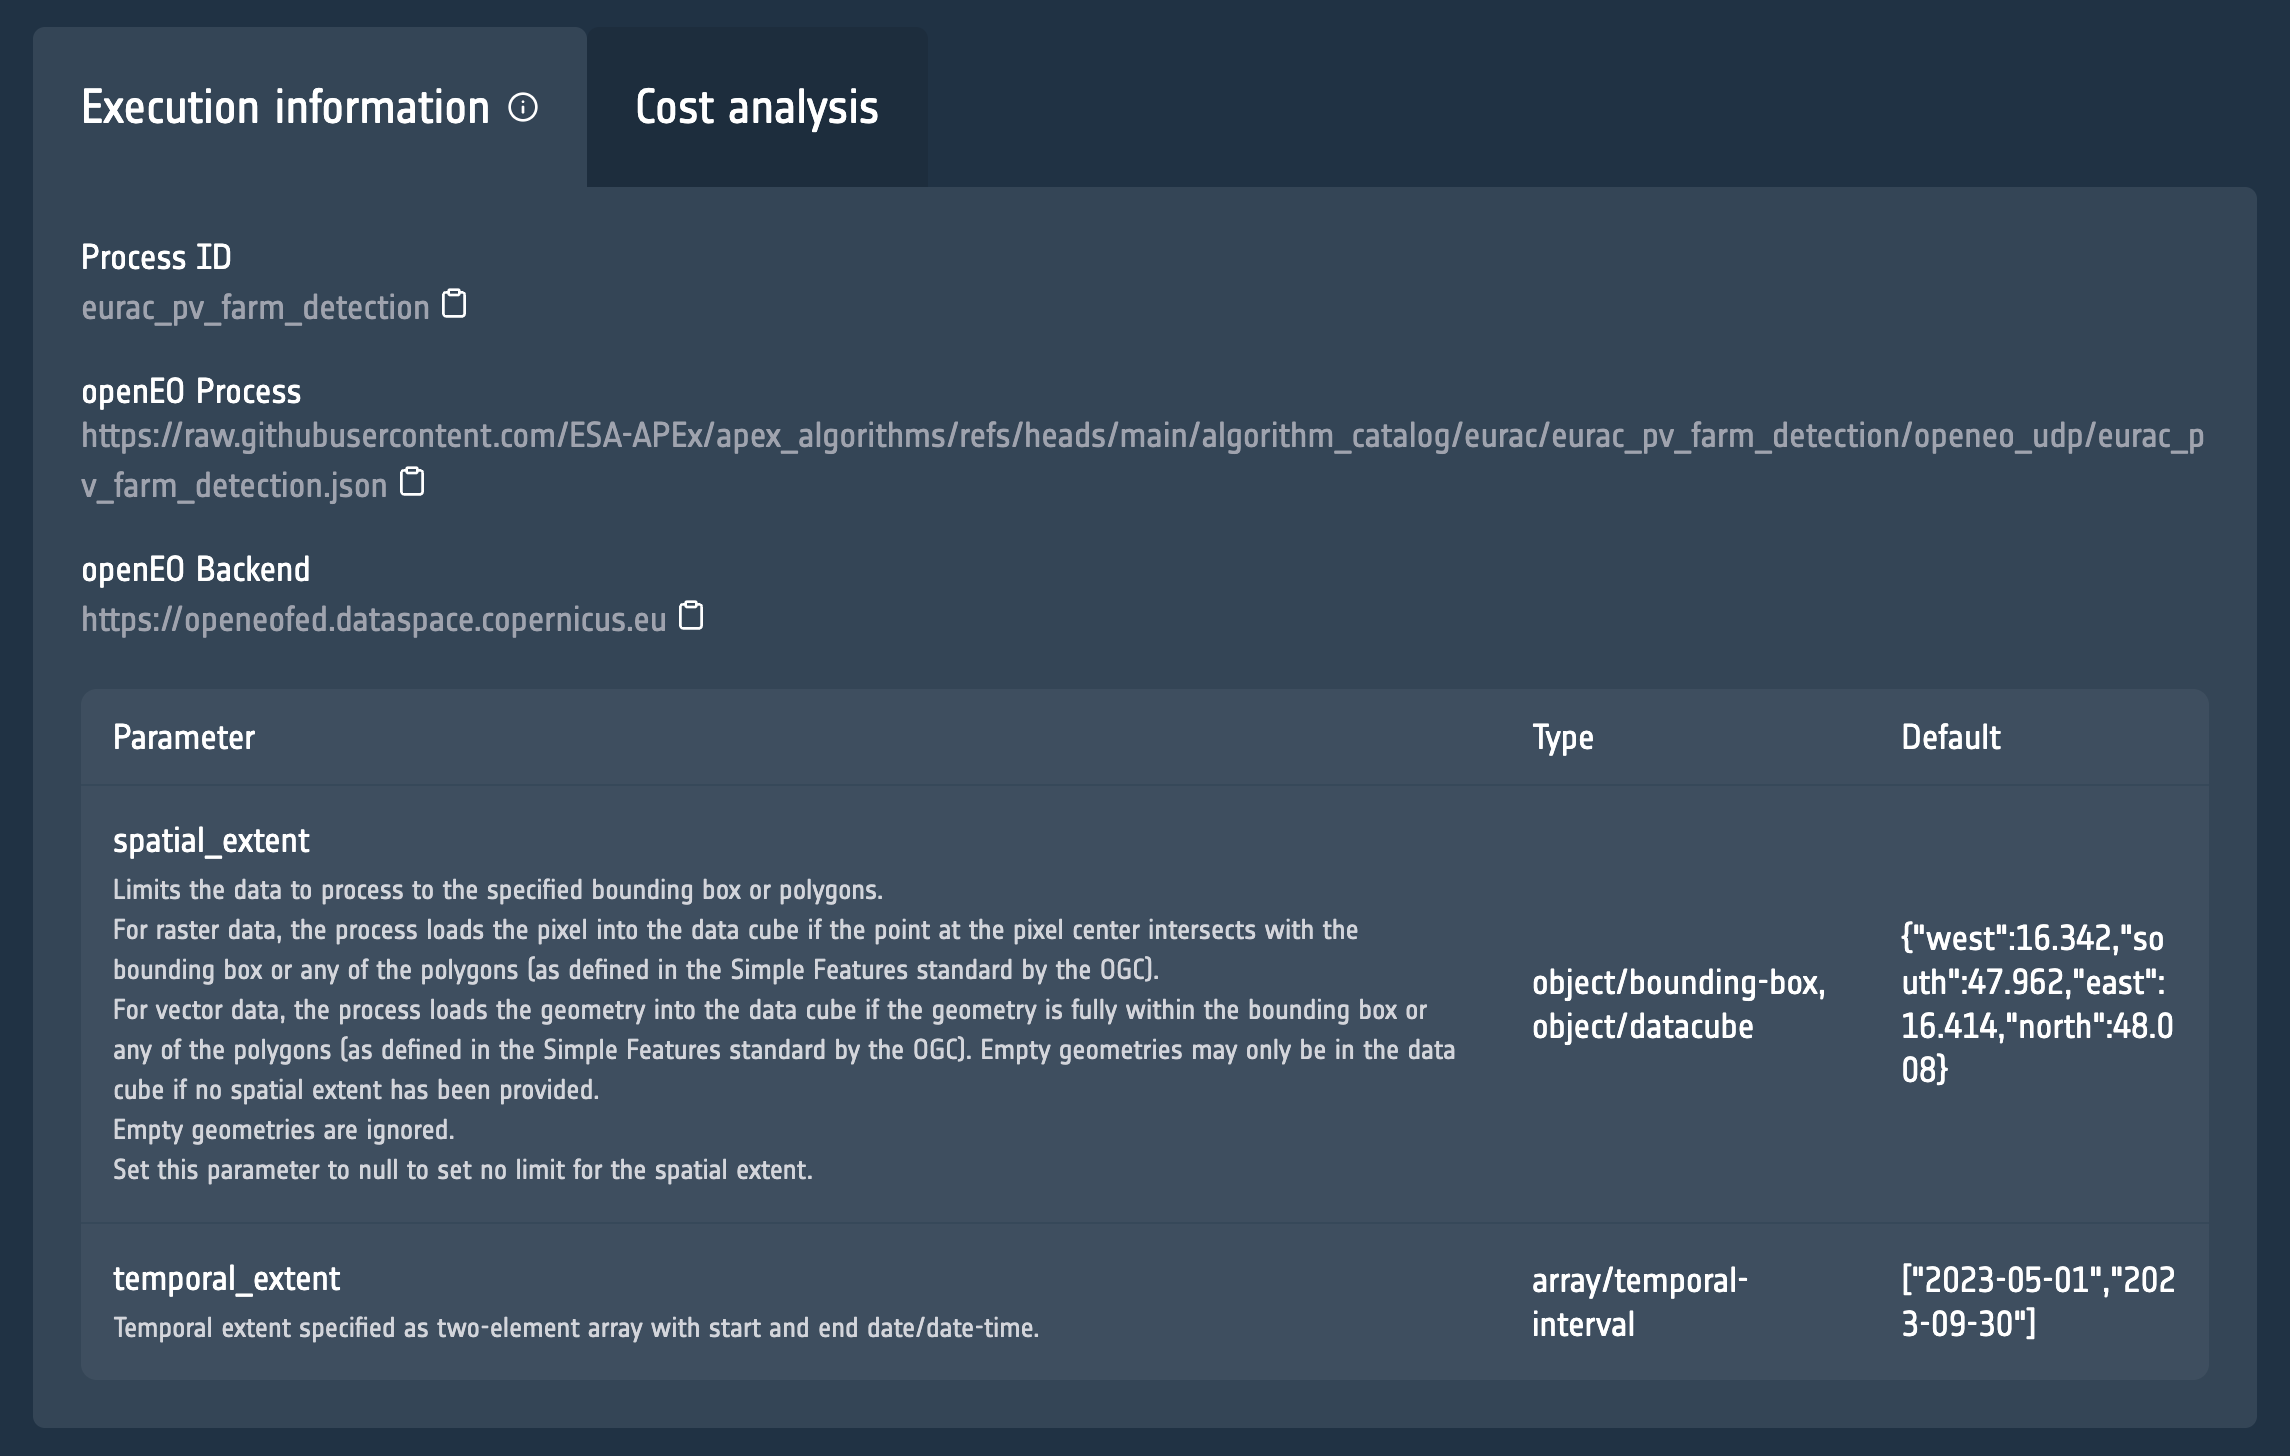

## Supported Services

Please access our [documentation](../propagation/upscaling.md#supported-platforms-and-services) to learn which of the platforms and services are supported by the APEx Dispatch API.

## Prerequisites

It is important to highlight that you will need to have access to the [Copernicus Data Space Ecosytem](https://documentation.dataspace.copernicus.eu/Registration.html") in order to execute this notebook.


## Setting up the parameters

Before diving into the code to call the APEx Dispatch API, we start by defining the parameters that we will be using for executing the PV Farm Detection service.

In [1]:
process_url = "https://raw.githubusercontent.com/ESA-APEx/apex_algorithms/refs/heads/main/algorithm_catalog/eurac/eurac_pv_farm_detection/openeo_udp/eurac_pv_farm_detection.json"
backend = "https://openeofed.dataspace.copernicus.eu"

In [2]:
spatial_extent = {
    "west": 16.342,
    "south": 47.962,
    "east": 16.414,
    "north": 48.008
}
temporal_extent = ["2023-05-01", "2023-09-30"]
output_format = "gtiff"

## Authentication with the API
To access the different endpoints of the Dispatcher API it is important to first authenticate yourself with the APEx environment. 

**NOTE**
Please ensure that your CDSE account is linked to APEx account, as described [here](../propagation/upscaling.md#platform-account-linking).


In [3]:
KEYCLOAK_HOST = "auth.apex.esa.int"
CLIENT_ID = "apex-dispatcher-api-prod"

In [4]:
from authlib.integrations.requests_client import OAuth2Session
from urllib.parse import urlparse, parse_qs
import time

# Endpoints
authorization_endpoint = f"https://{KEYCLOAK_HOST}/realms/apex/protocol/openid-connect/auth"
token_endpoint = f"https://{KEYCLOAK_HOST}/realms/apex/protocol/openid-connect/token"

# Global token store
_token_data = None

def get_access_token():
    """
    Returns a valid access token. Refreshes it automatically if expired.
    """
    global _token_data

    # If we have a token and it hasn't expired yet, return it
    if _token_data and _token_data.get("expires_at", 0) > time.time() + 10:
        return _token_data["access_token"]

    # If token exists but is expired and has a refresh_token, refresh it
    if _token_data and "refresh_token" in _token_data:
        session = OAuth2Session(CLIENT_ID, token=_token_data)
        _token_data = session.refresh_token(token_endpoint)
        return _token_data["access_token"]

    # Otherwise, start a new OAuth2 flow
    session = OAuth2Session(
        client_id=CLIENT_ID,
        redirect_uri="http://localhost:8000/callback"
    )
    uri, state = session.create_authorization_url(authorization_endpoint)
    print("Open this URL in your browser:", uri)
    redirect_url = input("Paste the redirect URL here: ")
    parsed = urlparse(redirect_url)
    code = parse_qs(parsed.query).get("code")[0]

    _token_data = session.fetch_token(
        token_endpoint,
        code=code,
        client_secret=None,  # only if your client is confidential
        include_client_id=True
    )

    return _token_data["access_token"]

## Launching the service execution task

Next we trigger the service execution task on the dispatcher. We provide the details of the processing job that needs to be executed. The result is the information on the created service execution task.

You will be requested to login to APEx, please use the **CDSE** option to login using your CDSE account.

In [5]:
import requests

execution_task = requests.post(
    f"http://dispatch-api.apex.esa.int/unit_jobs", 
    headers={
        "Authorization": f"Bearer {get_access_token()}"        
    },
    json={
        "title": "PV Farm Detection",
        "label": "openeo",
        "service": {
           "endpoint": backend,
           "application": process_url
        },
        "format": output_format,
        "parameters": {
            "spatial_extent": spatial_extent,
            "temporal_extent": temporal_extent
        }
    }
)
execution_task_id = execution_task.json()['id']

Open this URL in your browser: https://auth.apex.esa.int/realms/apex/protocol/openid-connect/auth?response_type=code&client_id=apex-dispatcher-api-prod&redirect_uri=http%3A%2F%2Flocalhost%3A8000%2Fcallback&state=xN8mk1EvBbR0lviZnJuu7K7WmLkNUP


Paste the redirect URL here:  http://localhost:8000/callback?state=xN8mk1EvBbR0lviZnJuu7K7WmLkNUP&session_state=41FFx4Vs05fRIpn1PAnD_7mK&iss=https%3A%2F%2Fauth.apex.esa.int%2Frealms%2Fapex&code=c9e2a779-efab-3510-8b02-2e05030818b9.41FFx4Vs05fRIpn1PAnD_7mK.3aa033f5-470c-405e-b6f0-b5bbf9e380fd


## Setting up map visualization

The following code is needed to support the visualization of the execution status and final results on a map. 

In [6]:
import folium
import folium.raster_layers
import rasterio
import numpy as np
from rasterio.warp import transform_bounds
from pyproj import Transformer
from PIL import Image
import base64
import io
from IPython.display import clear_output, display

In [7]:
def add_cog_layer(cog_url, name=None, m=None):
    """Add a Cloud-Optimized GeoTIFF layer to the folium map."""
    with rasterio.open(cog_url) as src:
        band = src.read(1).astype(np.float32)
        bounds = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
        
        # Normalize 0–255
        band = 255 * (band - band.min()) / (band.max() - band.min())
        band = band.astype(np.uint8)

    # Convert to PNG data URI
    buf = io.BytesIO()
    Image.fromarray(band).save(buf, format="PNG")
    data_url = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("utf-8")

    # bounds format: (west, south, east, north)
    bbox = [[bounds[1], bounds[0]], [bounds[3], bounds[2]]]
    overlay = folium.raster_layers.ImageOverlay(
        image=data_url,
        bounds=bbox,
        name=name or "COG",
        opacity=0.8
    )
    if m:
        overlay.add_to(m)
    return overlay

def add_geojson_layer(url, name=None, m=None):
    """Add a GeoJSON layer to the folium map."""
    data = requests.get(url).json()
    if "crs" in data and "properties" in data["crs"]:
        transformer = Transformer.from_crs(
            data["crs"]["properties"]["name"], 
            "EPSG:4326", 
            always_xy=True
        )
        for feature in data["features"]:
            geom = feature["geometry"]
            if geom["type"] == "Polygon":
                new_coords = []
                for ring in geom["coordinates"]:
                    new_ring = [list(transformer.transform(x, y)) for x, y in ring]
                    new_coords.append(new_ring)
                geom["coordinates"] = new_coords
    
    geo_layer = folium.GeoJson(data=data, name=name or "GeoJSON")
    if m:
        geo_layer.add_to(m)
    return geo_layer

In [8]:
# Compute center and create map function
west = spatial_extent["west"]
south = spatial_extent["south"]
east = spatial_extent["east"]
north = spatial_extent["north"]
center_lat = (south + north) / 2
center_lon = (west + east) / 2

# Color map for job statuses
color_map = {
    "created": "blue",
    "queued": "orange",
    "running": "yellow",
    "finished": "lime",
    "canceled": "gray",
    "failed": "red",
    None: "grey"
}

def plot_job_status(job_data):
    """Create a fresh folium map with current job status."""
    status = job_data.get("status", "unknown")
    color = color_map.get(status, "black")
    
    # Create a new map for each update
    status_map = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=10,
        tiles="CartoDB positron"
    )
    
    # Create bounds from spatial extent
    bounds = [
        [spatial_extent["south"], spatial_extent["west"]],
        [spatial_extent["north"], spatial_extent["east"]]
    ]
    
    # Add rectangle for job area
    folium.Rectangle(
        bounds=bounds,
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0 if status == "finished" else 0.3,
        weight=2,
        popup=f"Job {execution_task_id}: {status}"
    ).add_to(status_map)

    # Fit bounds to extent
    status_map.fit_bounds(bounds)
    
    return status_map

# Display initial map
m = plot_job_status({"status": "created"})

## Retrieve status of the service execution task
We can now write a continuous monitoring process that fetches the status of the service execution task and showcase the results on the map.


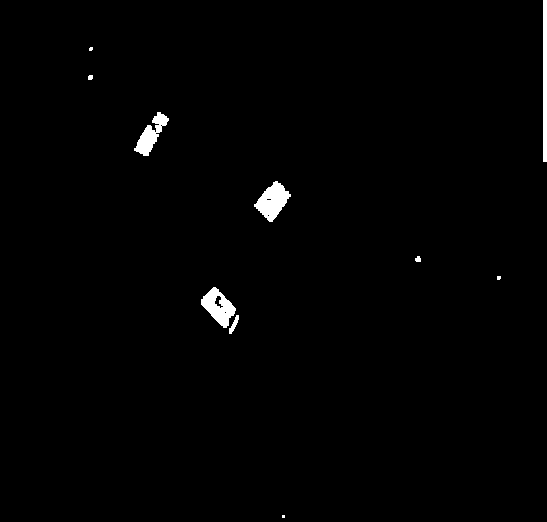

In [10]:
async def show_results(job_id):
    """Retrieve and display job results on the map."""
    result = requests.get(
        f"http://dispatch-api.apex.esa.int/unit_jobs/{job_id}/results",
        headers={"Authorization": f"Bearer {get_access_token()}"}
    )
    response = result.json()
    
    # Recreate map with results overlay
    results_map = plot_job_status({"status": "finished"})
    
    if output_format.lower() == "geojson":
        result_url = response["assets"]["vectorcube.geojson"]["href"]
        add_geojson_layer(result_url, name=f"Job {job_id} Results", m=results_map)
    else:
        cog_url = response["assets"]["openEO.tif"]["href"]
        add_cog_layer(cog_url, name=f"Job {job_id} Results", m=results_map)
    
    clear_output(wait=True)
    display(results_map)
    return response

async def listen_for_updates():
    """Monitor job status and update map accordingly."""
    finished = False
    while not finished:
        response = requests.get(
            f"http://dispatch-api.apex.esa.int/unit_jobs/{execution_task_id}",
            headers={"Authorization": f"Bearer {get_access_token()}"}
        )
        job = response.json()
        
        # Plot updated status
        status_map = plot_job_status(job)
        clear_output(wait=True)
        display(status_map)
        
        if job["status"] == "finished":
            await show_results(job["id"])

        finished = job['status'] in ["finished", "canceled", "failed"]
        if not finished:
            time.sleep(3)

# Run the monitoring process
await listen_for_updates()